# Введение в обучение с подкреплением (Reinforcement Learning)

**Решение лабораторной работы**

Темы:
* Reinforcement Learning (RL)
* Random Policy Search
* Policy Gradient (REINFORCE)
* Q-Learning

## Настройка среды

In [1]:
%%capture
!pip install jaxlib
!pip install jax
!pip install git+https://github.com/deepmind/dm-haiku
!pip install "gym==0.25"
!pip install "gym[box2d]"
!pip install optax
!pip install matplotlib
!pip install chex
!pip install "gym[classic_control]"

In [19]:
%%capture
import copy
from shutil import rmtree
import random
import collections
import numpy as np
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_
if not hasattr(np, 'float_'):
    np.float_ = np.float64
if not hasattr(np, 'int_'):
    np.int_ = np.int64
import gym
from gym.wrappers import RecordVideo
import jax
import jax.numpy as jnp
import haiku as hk
import optax
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import chex

import warnings
warnings.filterwarnings('ignore')

## 1. Ключевые концепции

In [3]:
env_name = "CartPole-v0"
env = gym.make(env_name)

s_0 = env.reset()
print("Initial State:", s_0)

obs_shape = env.observation_space.shape
print("Observation Space Shape:", obs_shape)

print(f"Action space: {env.action_space}")
num_actions = env.action_space.n
print(f"Number of actions: {num_actions}")

Initial State: [-0.01737455 -0.00280289  0.02226256 -0.00712468]
Observation Space Shape: (4,)
Action space: Discrete(2)
Number of actions: 2


### Упражнение 1 — Линейная политика

In [4]:
def linear_policy(params, obs):
    """
    Простая линейная политика.
    1. Вычисляет скалярное произведение params и obs.
    2. Если результат > 0 — возвращает 1, иначе 0.
    """
    dot_product_result = jnp.dot(params, obs)

    action = jax.lax.select(
        dot_product_result > 0,  # условие
        1,                        # если True
        0                         # если False
    )
    return action

In [5]:
# Проверка упр. 1
def check_linear_policy(linear_policy):
    fixed_obs = jnp.array([1,1,2,4])
    params1 = jnp.array([1,1,1,1])
    params2 = jnp.array([-1,-1,-1,-1])

    hint = None
    if linear_policy(params1, fixed_obs) != 1:
        hint = f"Неправильный ответ при params={params1}: должно быть 1"
    elif linear_policy(params2, fixed_obs) != 0:
        hint = f"Неправильный ответ при params={params2}: должно быть 0"

    print(hint if hint else "Your function is correct!")

try:
    check_linear_policy(linear_policy)
except Exception as e:
    print("An Error Occurred:", e)

Your function is correct!


### Упражнение 2 — Цикл агент-среда (run_episode)

In [6]:
def run_episode(env):
    episode_return = 0
    done = False
    params = jnp.array([1, -2, 2, -1])

    obs = env.reset()           # получаем начальное наблюдение

    while not done:
        action = linear_policy(params, obs)        # выбираем действие
        action = np.array(action)                  # конвертируем в np.array

        obs, reward, done, info = env.step(action) # делаем шаг в среде

        episode_return += reward                   # накапливаем награду

    return episode_return

In [7]:
# Проверка упр. 2
try:
    env.seed(42)
    result = run_episode(env)
    print("Looks correct!" if result == 31 else f"Looks like your implementation might be wrong. Got: {result}")
except Exception as e:
    print("An Error Occurred:", e)

An Error Occurred: module 'numpy' has no attribute 'bool8'


## 2. Случайный поиск политики (Random Policy Search)

In [8]:
RandomPolicySearchParams = collections.namedtuple("RandomPolicySearchParams", ["current", "best"])

current_params = np.ones(obs_shape) * -1
best_params = np.zeros(obs_shape)
rps_params = RandomPolicySearchParams(current_params, best_params)

print(f"Best params: {rps_params.best}")
print(f"Current params: {rps_params.current}")

Best params: [0. 0. 0. 0.]
Current params: [-1. -1. -1. -1.]


### Упражнение 3 — Функция выбора действия RPS

In [9]:
def random_policy_search_choose_action(key, params, actor_state, obs, evaluation=False):
    """
    Выбор действия для RPS.
    Если evaluation=True — используем 'best' параметры,
    иначе — 'current'.
    """
    best_action    = linear_policy(params.best, obs)
    current_action = linear_policy(params.current, obs)

    action = jax.lax.select(
        evaluation,     # условие
        best_action,    # если evaluation=True
        current_action  # если evaluation=False
    )

    return action, actor_state

In [10]:
# Проверка упр. 3
def check_random_policy_search_choose_action(choose_action):
    key = None
    actor_state = None
    obs = np.ones(obs_shape)

    current_params = np.ones(obs_shape) * -1
    best_params    = np.ones(obs_shape)
    rps_params     = RandomPolicySearchParams(current_params, best_params)

    action, _ = choose_action(key, rps_params, actor_state, obs, evaluation=False)
    if action != 0:
        return False

    action, _ = choose_action(key, rps_params, actor_state, obs, evaluation=True)
    if action != 1:
        return False

    return True

try:
    result = check_random_policy_search_choose_action(random_policy_search_choose_action)
    print("Your function looks correct." if result else "Your function looks incorrect.")
except Exception as e:
    print("An Error Occurred:", e)

Your function looks correct.


In [11]:
# Буфер памяти для RPS (готовый код)
class AverageEpisodeReturnBuffer:
    def __init__(self, num_episodes_to_store=50):
        self.num_episodes_to_store = num_episodes_to_store
        self.episode_return_buffer = []
        self.current_episode_return = 0

    def push(self, transition):
        self.current_episode_return += transition.reward
        if transition.done:
            self.episode_return_buffer.append(self.current_episode_return)
            self.current_episode_return = 0

    def is_ready(self):
        return len(self.episode_return_buffer) == self.num_episodes_to_store

    def sample(self):
        avg = np.mean(self.episode_return_buffer)
        self.episode_return_buffer = []
        return avg

### Упражнение 4 — Генерация случайных весов

In [12]:
def get_new_random_weights(random_key, old_weights, minval=-2.0, maxval=2.0):
    """
    Генерирует новые случайные веса той же формы и типа,
    что и old_weights, из диапазона [minval, maxval].
    """
    new_weights_shape = old_weights.shape
    new_weights_dtype = old_weights.dtype

    new_params = jax.random.uniform(
        random_key,
        shape=new_weights_shape,
        dtype=new_weights_dtype,
        minval=minval,
        maxval=maxval
    )

    return new_params

In [13]:
# Проверка упр. 4
def check_get_new_random_weights(fn):
    old_weights = np.ones(obs_shape, "float32")
    random_key  = jax.random.PRNGKey(42)
    new_weights = fn(random_key, old_weights, minval=-2.0, maxval=2.0)

    expected = jnp.array([0.29657745, 1.4265499, -1.7621555, -1.7505779])
    print("Function is correct!" if jnp.array_equal(new_weights, expected) else "Something is wrong.")

try:
    check_get_new_random_weights(get_new_random_weights)
except Exception as e:
    print("An Error Occurred:", e)

Something is wrong.


### Упражнение 5 — Функция обучения RPS

In [14]:
RandomPolicyLearnState = collections.namedtuple(
    "RandomPolicyLearnState",
    ["best_average_episode_return"]
)

initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))
print("Initial best average episode return:", initial_learn_state.best_average_episode_return)

Initial best average episode return: -inf


In [15]:
def random_policy_search_learn(key, params, learn_state, memory):
    """
    Если текущие параметры лучше лучших — обновляем best.
    Затем генерируем новые случайные current.
    """
    best_params    = params.best
    current_params = params.current

    current_average_episode_return = memory
    best_average_episode_return    = learn_state.best_average_episode_return

    is_better = current_average_episode_return > best_average_episode_return

    # Обновляем best_params если текущие лучше
    best_params = jax.lax.select(
        is_better,
        current_params,  # если лучше — берём current
        best_params      # иначе оставляем best
    )

    # Обновляем лучший средний возврат
    best_average_episode_return = jax.lax.select(
        is_better,
        current_average_episode_return,  # обновляем
        best_average_episode_return      # оставляем
    )

    # Генерируем новые случайные параметры
    new_params = get_new_random_weights(key, current_params)

    params = RandomPolicySearchParams(current=new_params, best=best_params)

    return params, RandomPolicyLearnState(best_average_episode_return)

In [16]:
# Проверка упр. 5
params     = RandomPolicySearchParams(np.ones(obs_shape, "float32"), np.ones(obs_shape, "float32") * -1)
learn_state = RandomPolicyLearnState(10)
memory     = 11
key        = jax.random.PRNGKey(42)

try:
    new_params, new_learn_state = random_policy_search_learn(key, params, learn_state, memory)

    ok = True
    if not jnp.array_equal(new_params.current, jnp.array([0.29657745, 1.4265499, -1.7621555, -1.7505779])):
        ok = False
    if not jnp.array_equal(new_params.best, jnp.array([1., 1., 1., 1.])):
        ok = False
    if new_learn_state.best_average_episode_return != 11:
        ok = False

    print("Your function looks correct." if ok else "Your function is incorrect.")
except Exception as e:
    print("An Error Occurred:", e)

Your function is incorrect.


### Цикл обучения RPS

In [17]:
# Готовый цикл обучения (run me)
Transition = collections.namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done"])

def run_training_loop(env_name, agent_params, agent_select_action_func,
    agent_actor_state=None, agent_learn_func=None, agent_learner_state=None,
    agent_memory=None, num_episodes=1000, evaluator_period=100,
    evaluation_episodes=8, learn_steps_per_episode=1,
    train_every_timestep=False, video_subdir=""):

    env      = gym.make(env_name, render_mode="rgb_array")
    eval_env = gym.make(env_name, render_mode="rgb_array")

    video_dir = "./video" + "/" + video_subdir
    try:
        rmtree(video_dir)
    except:
        pass

    env      = RecordVideo(env,      video_dir+"/train", episode_trigger=lambda x: (x % evaluator_period) == 0)
    eval_env = RecordVideo(eval_env, video_dir+"/eval",  episode_trigger=lambda x: (x % evaluation_episodes) == 0)

    rng = hk.PRNGSequence(jax.random.PRNGKey(0))
    env.seed(0)
    random.seed(0)

    episode_returns           = []
    evaluator_episode_returns = []
    timesteps = 0

    for episode in range(num_episodes):
        obs            = env.reset()
        episode_return = 0
        done           = False

        while not done:
            action, agent_actor_state = agent_select_action_func(
                next(rng), agent_params, agent_actor_state, np.array(obs)
            )
            next_obs, reward, done, _ = env.step(int(action))
            transition = Transition(obs, action, reward, next_obs, done)

            if agent_memory:
                agent_memory.push(transition)

            episode_return += reward
            obs = next_obs
            timesteps += 1

            if train_every_timestep and (timesteps % 4 == 0) and agent_memory and agent_memory.is_ready():
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                    next(rng), agent_params, agent_learner_state, memory
                )

        episode_returns.append(episode_return)

        if agent_memory and agent_memory.is_ready():
            for _ in range(learn_steps_per_episode):
                memory = agent_memory.sample()
                agent_params, agent_learner_state = agent_learn_func(
                    next(rng), agent_params, agent_learner_state, memory
                )

        if (episode % evaluator_period) == 0:
            evaluator_episode_return = 0
            for eval_episode in range(evaluation_episodes):
                obs  = eval_env.reset()
                done = False
                while not done:
                    action, _ = agent_select_action_func(
                        next(rng), agent_params, agent_actor_state, np.array(obs), evaluation=True
                    )
                    obs, reward, done, _ = eval_env.step(int(action))
                    evaluator_episode_return += reward

            evaluator_episode_return /= evaluation_episodes
            evaluator_episode_returns.append(evaluator_episode_return)

            print(f"Episode: {episode}\tEpisode Return: {episode_return}\t"
                  f"Avg Return (last 20): {np.mean(episode_returns[-20:]):.1f}\t"
                  f"Evaluator Return: {evaluator_episode_return:.1f}")

    env.close()
    eval_env.close()

    return episode_returns, evaluator_episode_returns

Starting training (RPS). This may take a few minutes...
Episode: 0	Episode Return: 80.0	Avg Return (last 20): 80.0	Evaluator Return: 154.5
Episode: 100	Episode Return: 57.0	Avg Return (last 20): 192.8	Evaluator Return: 200.0
Episode: 200	Episode Return: 25.0	Avg Return (last 20): 10.3	Evaluator Return: 200.0
Episode: 300	Episode Return: 9.0	Avg Return (last 20): 9.2	Evaluator Return: 200.0
Episode: 400	Episode Return: 191.0	Avg Return (last 20): 18.6	Evaluator Return: 200.0
Episode: 500	Episode Return: 200.0	Avg Return (last 20): 77.0	Evaluator Return: 200.0
Episode: 600	Episode Return: 9.0	Avg Return (last 20): 9.2	Evaluator Return: 200.0
Episode: 700	Episode Return: 10.0	Avg Return (last 20): 9.7	Evaluator Return: 200.0
Episode: 800	Episode Return: 200.0	Avg Return (last 20): 125.4	Evaluator Return: 200.0
Episode: 900	Episode Return: 114.0	Avg Return (last 20): 139.7	Evaluator Return: 200.0
Episode: 1000	Episode Return: 9.0	Avg Return (last 20): 63.8	Evaluator Return: 200.0


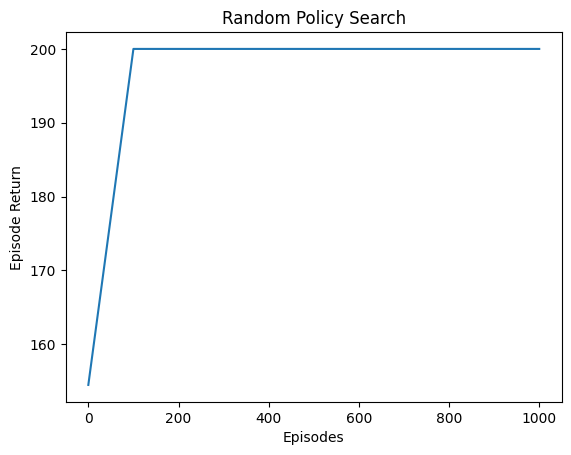

In [20]:
random_policy_search_learn_jit       = jax.jit(random_policy_search_learn)
random_policy_search_choose_action_jit = jax.jit(random_policy_search_choose_action)

initial_weights     = np.ones(obs_shape, "float32")
initial_params      = RandomPolicySearchParams(initial_weights, initial_weights)
initial_learn_state = RandomPolicyLearnState(best_average_episode_return=-float("inf"))
memory              = AverageEpisodeReturnBuffer(num_episodes_to_store=50)

print("Starting training (RPS). This may take a few minutes...")
chex.clear_trace_counter()
episode_return, evaluator_episode_returns = run_training_loop(
    env_name,
    initial_params,
    random_policy_search_choose_action_jit,
    None,
    random_policy_search_learn_jit,
    initial_learn_state,
    memory,
    num_episodes=1001,
    video_subdir="rps"
)

plt.plot(np.linspace(0, 1000, len(evaluator_episode_returns)), evaluator_episode_returns)
plt.title("Random Policy Search")
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.show()

## 3. Policy Gradient (REINFORCE)

### Упражнение 6 — Взвешенный логарифм вероятности

In [21]:
def compute_weighted_log_prob(action_prob, episode_return):
    """
    Вычисляет log(action_prob) * episode_return.
    Используется в градиенте политики.
    """
    log_prob          = jnp.log(action_prob)
    weighted_log_prob = log_prob * episode_return
    return weighted_log_prob

In [22]:
# Проверка упр. 6
try:
    result = compute_weighted_log_prob(0.8, 100)
    print("Looks correct." if result == -22.314354 else f"Incorrect: got {result}")
except Exception as e:
    print("An Error Occurred:", e)

Looks correct.


### Упражнение 7 — Rewards-to-go

In [23]:
def compute_rewards_to_go(rewards):
    """
    Вычисляет rewards-to-go для каждого шага.
    Пример: [1,2,3,4] -> [10, 9, 7, 4]
    rewards_to_go[t] = sum(rewards[t:])
    """
    rewards_to_go = []

    running_sum = 0
    # Идём с конца к началу, накапливая сумму
    for reward in reversed(rewards):
        running_sum += reward
        rewards_to_go.insert(0, running_sum)

    return rewards_to_go

In [24]:
# Проверка упр. 7
try:
    result = compute_rewards_to_go([1, 2, 3, 4])
    print("Looks correct." if result == [10, 9, 7, 4] else f"Problem: got {result}")
except Exception as e:
    print("An Error Occurred:", e)

Looks correct.


In [25]:
# Память REINFORCE
EpisodeRewardsToGoMemory = collections.namedtuple(
    "EpisodeRewardsToGoMemory", ["obs", "action", "reward_to_go"]
)

class EpisodeRewardsToGoBuffer:
    def __init__(self, num_transitions_to_store=512, batch_size=256):
        self.batch_size = batch_size
        self.memory_buffer = collections.deque(maxlen=num_transitions_to_store)
        self.current_episode_transition_buffer = []

    def push(self, transition):
        self.current_episode_transition_buffer.append(transition)
        if transition.done:
            episode_rewards = [t.reward for t in self.current_episode_transition_buffer]
            r2g = compute_rewards_to_go(episode_rewards)
            for i, t in enumerate(self.current_episode_transition_buffer):
                self.memory_buffer.append(EpisodeRewardsToGoMemory(t.obs, t.action, r2g[i]))
            self.current_episode_transition_buffer = []

    def is_ready(self):
        return len(self.memory_buffer) >= self.batch_size

    def sample(self):
        sample = random.sample(self.memory_buffer, self.batch_size)
        obs_batch, action_batch, r2g_batch = zip(*sample)
        return EpisodeRewardsToGoMemory(
            np.stack(obs_batch).astype("float32"),
            np.asarray(action_batch).astype("int32"),
            np.asarray(r2g_batch).astype("int32")
        )

REINFORCE_memory = EpisodeRewardsToGoBuffer(num_transitions_to_store=512, batch_size=256)

In [26]:
# Нейросеть политики
def make_policy_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
    def policy_network(obs):
        network = hk.Sequential([hk.Flatten(), hk.nets.MLP(layers + [num_actions])])
        return network(obs)
    return hk.without_apply_rng(hk.transform(policy_network))

POLICY_NETWORK  = make_policy_network(num_actions=num_actions, layers=[20, 20])
random_key      = jax.random.PRNGKey(42)
dummy_obs       = np.ones(obs_shape, "float32")
REINFORCE_params = POLICY_NETWORK.init(random_key, dummy_obs)

print("Initial params:", REINFORCE_params.keys())
print("Policy network output:", POLICY_NETWORK.apply(REINFORCE_params, dummy_obs))

Initial params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])
Policy network output: [0.29175335 0.04247757]


### Упражнение 8 — Выборка действия из логитов

In [27]:
def sample_action(random_key, logits):
    """
    Случайно выбирает действие из категориального распределения,
    заданного логитами.
    """
    action = jax.random.categorical(random_key, logits)
    return action

In [28]:
# Проверка упр. 8
try:
    random_key = jax.random.PRNGKey(42)
    action = sample_action(random_key, np.array([1, 2], "float32"))
    print("Seems correct." if action == 1 else f"Incorrect: got {action}")
except Exception as e:
    print("An Error Occurred:", e)

Seems correct.


In [29]:
# Функция выбора действия REINFORCE
def REINFORCE_choose_action(key, params, actor_state, obs, evaluation=False):
    obs    = jnp.expand_dims(obs, axis=0)
    logits = POLICY_NETWORK.apply(params, obs)[0]
    action = sample_action(key, logits)
    return action, actor_state

### Упражнение 9 — Policy gradient loss

In [30]:
def policy_gradient_loss(action, logits, reward_to_go):
    """
    Вычисляет потерю градиента политики для одного перехода.
    loss = -log(pi(a|s)) * R
    """
    all_action_probs = jax.nn.softmax(logits)   # логиты -> вероятности
    action_prob      = all_action_probs[action]  # вероятность выбранного действия
    weighted_log_prob = compute_weighted_log_prob(action_prob, reward_to_go)

    loss = -weighted_log_prob  # минус, т.к. хотим градиентный подъём
    return loss

In [31]:
# Проверка упр. 9
try:
    result = policy_gradient_loss(1, np.array([1, 2], "float32"), 10)
    print("Looks correct." if result == 3.1326175 else f"Incorrect: got {result}")
except Exception as e:
    print("An Error Occurred:", e)

Incorrect: got 3.1326165199279785


In [32]:
# Batched loss + оптимизатор + функция обучения
def batched_policy_gradient_loss(params, obs_batch, action_batch, reward_to_go_batch):
    logits_batch = POLICY_NETWORK.apply(params, obs_batch)
    losses = jax.vmap(policy_gradient_loss)(action_batch, logits_batch, reward_to_go_batch)
    return jnp.mean(losses)

REINFORCE_OPTIMIZER  = optax.adam(1e-3)
REINFORCE_optim_state = REINFORCE_OPTIMIZER.init(REINFORCE_params)

REINFORCELearnState = collections.namedtuple("LearnerState", ["optim_state"])

def REINFORCE_learn(key, params, learner_state, memory):
    grad_loss = jax.grad(batched_policy_gradient_loss)(
        params, memory.obs, memory.action, memory.reward_to_go
    )
    updates, new_optim_state = REINFORCE_OPTIMIZER.update(grad_loss, learner_state.optim_state)
    params = optax.apply_updates(params, updates)
    return params, REINFORCELearnState(new_optim_state)

### Цикл обучения REINFORCE

Starting training (REINFORCE). This may take up to 10 minutes...
Episode: 0	Episode Return: 8.0	Avg Return (last 20): 8.0	Evaluator Return: 21.8
Episode: 100	Episode Return: 48.0	Avg Return (last 20): 80.3	Evaluator Return: 122.9
Episode: 200	Episode Return: 200.0	Avg Return (last 20): 156.3	Evaluator Return: 200.0
Episode: 300	Episode Return: 200.0	Avg Return (last 20): 193.8	Evaluator Return: 200.0
Episode: 400	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.0
Episode: 500	Episode Return: 200.0	Avg Return (last 20): 190.4	Evaluator Return: 176.9
Episode: 600	Episode Return: 200.0	Avg Return (last 20): 185.1	Evaluator Return: 189.1
Episode: 700	Episode Return: 200.0	Avg Return (last 20): 180.7	Evaluator Return: 173.5
Episode: 800	Episode Return: 200.0	Avg Return (last 20): 197.8	Evaluator Return: 200.0
Episode: 900	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 189.9
Episode: 1000	Episode Return: 200.0	Avg Return (last 20): 197.7	Evaluator 

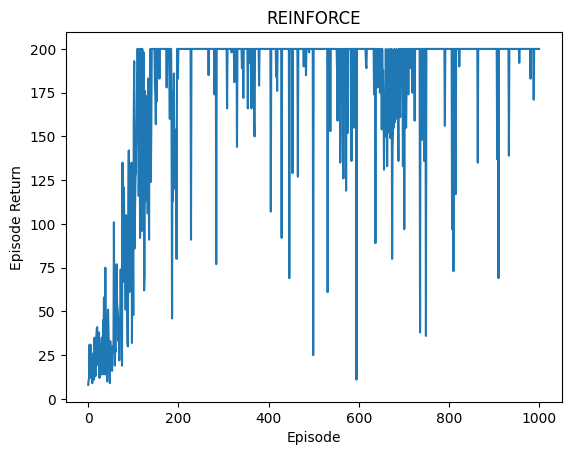

In [33]:
REINFORCE_learn_jit         = jax.jit(REINFORCE_learn)
REINFORCE_choose_action_jit = jax.jit(REINFORCE_choose_action)
REINFORCE_learn_state       = REINFORCELearnState(REINFORCE_optim_state)

print("Starting training (REINFORCE). This may take up to 10 minutes...")
episode_returns, evaluator_returns = run_training_loop(
    env_name,
    REINFORCE_params,
    REINFORCE_choose_action_jit,
    None,
    REINFORCE_learn_jit,
    REINFORCE_learn_state,
    REINFORCE_memory,
    num_episodes=1001,
    learn_steps_per_episode=2,
    video_subdir="reinforce"
)

plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Episode Return")
plt.title("REINFORCE")
plt.show()

## 4. Q-Learning

### Упражнение 10 — Жадный выбор действия

In [34]:
def select_greedy_action(q_values):
    """
    Возвращает действие с максимальным Q-значением.
    """
    action = jnp.argmax(q_values)
    return action

In [35]:
# Проверка упр. 10
try:
    q_values = jnp.array([1, 1, 3, 4])
    action   = select_greedy_action(q_values)
    print("Looks good." if action == 3 else f"Incorrect: got {action}")
except Exception as e:
    print("An Error Occurred:", e)

Looks good.


In [36]:
# Q-сеть (готовый код)
def build_network(num_actions: int, layers=[20, 20]) -> hk.Transformed:
    def q_network(obs):
        network = hk.Sequential([hk.Flatten(), hk.nets.MLP(layers + [num_actions])])
        return network(obs)
    return hk.without_apply_rng(hk.transform(q_network))

Q_NETWORK        = build_network(num_actions=num_actions, layers=[20, 20])
dummy_obs        = jnp.zeros((1, *obs_shape), jnp.float32)
random_key       = jax.random.PRNGKey(42)
Q_NETWORK_PARAMS = Q_NETWORK.init(random_key, dummy_obs)

print("Q-Network params:", Q_NETWORK_PARAMS.keys())

Q-Network params: dict_keys(['mlp/~/linear_0', 'mlp/~/linear_1', 'mlp/~/linear_2'])


### Упражнение 11 — Квадратичная ошибка

In [37]:
def compute_squared_error(pred, target):
    """
    Вычисляет квадрат разности: (pred - target)^2
    """
    squared_error = jnp.square(pred - target)
    return squared_error

In [38]:
# Проверка упр. 11
try:
    result = compute_squared_error(1, 4)
    print("Looks good." if result == 9 else f"Incorrect: got {result}")
except Exception as e:
    print("An Error Occurred:", e)

Looks good.


### Упражнение 12 — Цель Беллмана

In [39]:
def compute_bellman_target(reward, done, next_q_values):
    """
    Вычисляет цель Беллмана:
    - Если done=1: target = reward  (эпизод завершён, будущего нет)
    - Если done=0: target = reward + max(Q(s', a'))
    """
    max_next_q    = jnp.max(next_q_values)
    bellman_target = reward + (1.0 - done) * max_next_q
    return bellman_target

In [40]:
# Проверка упр. 12
try:
    result1 = compute_bellman_target(1, 0.0, np.array([3, 2], "float32"))  # не финал
    result2 = compute_bellman_target(1, 1.0, np.array([3, 2], "float32"))  # финал
    print("Looks good." if result1 == 4 and result2 == 1 else f"Incorrect: {result1}, {result2}")
except Exception as e:
    print("An Error Occurred:", e)

Looks good.


### Упражнение 13 — Q-learning loss

In [41]:
def q_learning_loss(q_values, action, reward, done, next_q_values):
    """
    Потеря Q-обучения: (Q(s,a) - bellman_target)^2
    """
    chosen_action_q_value = q_values[action]                               # Q-значение выбранного действия
    bellman_target        = compute_bellman_target(reward, done, next_q_values)  # цель Беллмана
    squared_error         = compute_squared_error(chosen_action_q_value, bellman_target)
    return squared_error

In [42]:
# Проверка упр. 13
try:
    result = q_learning_loss(np.array([3, 2], "float32"), 1, 2, 0.0, np.array([3, 2], "float32"))
    print("Looks good." if result == 9.0 else f"Incorrect: got {result}")
except Exception as e:
    print("An Error Occurred:", e)

Looks good.


In [43]:
# Target Q-network, оптимизатор, batched loss, q_learn
QLearnParams = collections.namedtuple("Params",       ["online", "target"])
QLearnState  = collections.namedtuple("LearnerState", ["count", "optim_state"])

Q_LEARN_OPTIMIZER    = optax.adam(3e-4)
Q_LEARN_OPTIM_STATE  = Q_LEARN_OPTIMIZER.init(Q_NETWORK_PARAMS)
Q_LEARNING_LEARN_STATE = QLearnState(0, Q_LEARN_OPTIM_STATE)
Q_LEARNING_PARAMS    = QLearnParams(online=Q_NETWORK_PARAMS, target=Q_NETWORK_PARAMS)

def update_target_params(learn_state, online_weights, target_weights):
    target = jax.lax.cond(
        jax.numpy.mod(learn_state.count, 100) == 0,
        lambda x, y: x,
        lambda x, y: y,
        online_weights,
        target_weights
    )
    return QLearnParams(online_weights, target)

def batched_q_learning_loss(online_params, target_params, obs, actions, rewards, next_obs, dones):
    q_values      = Q_NETWORK.apply(online_params, obs)
    next_q_values = Q_NETWORK.apply(target_params, next_obs)
    errors        = jax.vmap(q_learning_loss)(q_values, actions, rewards, dones, next_q_values)
    return jnp.mean(errors)

def q_learn(rng, params, learner_state, memory):
    grad_loss = jax.grad(batched_q_learning_loss)(
        params.online, params.target,
        memory.obs, memory.action, memory.reward, memory.next_obs, memory.done
    )
    updates, opt_state = Q_LEARN_OPTIMIZER.update(grad_loss, learner_state.optim_state)
    new_weights = optax.apply_updates(params.online, updates)
    params      = update_target_params(learner_state, new_weights, params.target)
    learner_state = QLearnState(learner_state.count + 1, opt_state)
    return params, learner_state

### Упражнение 14 — Случайное действие

In [45]:
def select_random_action(key, num_actions):
    """
    Возвращает случайное дискретное действие из [0, num_actions).
    """
    action = jax.random.randint(key, shape=(), minval=0, maxval=num_actions)
    return action

In [46]:
# Проверка упр. 14
try:
    result1 = select_random_action(jax.random.PRNGKey(6),    2)
    result2 = select_random_action(jax.random.PRNGKey(1000), 2)
    print("Looks good." if result1 == 1 and result2 == 0 else f"Incorrect: {result1}, {result2}")
except:
    print("Your implementation looks wrong.")

Incorrect: 0, 0


### Упражнение 15 — Epsilon decay

In [47]:
EPSILON_DECAY_TIMESTEPS = 3000
EPSILON_MIN = 0.1

def get_epsilon(num_timesteps):
    """
    Линейно уменьшает epsilon от 1.0 до EPSILON_MIN
    за EPSILON_DECAY_TIMESTEPS шагов.
    """
    epsilon = 1.0 - (num_timesteps / EPSILON_DECAY_TIMESTEPS) * (1.0 - EPSILON_MIN)

    epsilon = jax.lax.select(
        epsilon < EPSILON_MIN,
        EPSILON_MIN,  # если меньше минимума — ставим минимум
        epsilon       # иначе оставляем
    )
    return epsilon

In [48]:
# Проверка упр. 15
def check_get_epsilon(get_epsilon):
    try:
        result1 = get_epsilon(10)
        result2 = get_epsilon(5_010)
        print("Your function looks correct." if result1 == 0.99666667 and result2 == 0.1
              else f"Wrong: {result1}, {result2}")
    except:
        print("Your function looks wrong.")

check_get_epsilon(get_epsilon)

Wrong: 0.996999979019165, 0.10000000149011612


### Упражнение 16 — Epsilon-greedy выбор действия

In [49]:
def select_epsilon_greedy_action(key, q_values, num_timesteps):
    """
    С вероятностью epsilon выбирает случайное действие (исследование),
    иначе — жадное (эксплуатация).
    """
    num_actions = len(q_values)

    epsilon = get_epsilon(num_timesteps)

    # Разбиваем ключ на два: один для проверки epsilon, другой для случайного действия
    key1, key2 = jax.random.split(key)
    should_explore = jax.random.uniform(key1) < epsilon

    action = jax.lax.select(
        should_explore,
        select_random_action(key2, num_actions),  # случайное
        select_greedy_action(q_values)            # жадное
    )
    return action

In [50]:
# Проверка упр. 16
try:
    rng_check     = hk.PRNGSequence(jax.random.PRNGKey(42))
    dummy_q       = jnp.array([0, 1], jnp.float32)

    actions1 = [int(select_epsilon_greedy_action(next(rng_check), dummy_q, 5010)) for _ in range(10)]
    actions2 = [int(select_epsilon_greedy_action(next(rng_check), dummy_q, 0))    for _ in range(10)]

    expected1 = [1, 1, 0, 1, 1, 0, 1, 1, 1, 1]
    expected2 = [0, 0, 0, 1, 1, 1, 1, 0, 0, 0]

    print("Looks correct!" if actions1 == expected1 and actions2 == expected2
          else f"Might be incorrect!\nGot: {actions1}\nExpected: {expected1}")
except:
    print("Looks like something might be incorrect!")

Might be incorrect!
Got: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Expected: [1, 1, 0, 1, 1, 0, 1, 1, 1, 1]


In [51]:
# Функция выбора действия Q-learning + Replay Buffer
QActorState = collections.namedtuple("ActorState", ["count"])

def q_learning_select_action(key, params, actor_state, obs, evaluation=False):
    obs      = jnp.expand_dims(obs, axis=0)
    q_values = Q_NETWORK.apply(params.online, obs)[0]

    action        = select_epsilon_greedy_action(key, q_values, actor_state.count)
    greedy_action = select_greedy_action(q_values)

    action = jax.lax.select(evaluation, greedy_action, action)

    next_actor_state = QActorState(actor_state.count + 1)
    return action, next_actor_state

Q_LEARNING_ACTOR_STATE = QActorState(0)

class TransitionMemory(object):
    def __init__(self, max_size=10_000, batch_size=256):
        self.batch_size = batch_size
        self.buffer     = collections.deque(maxlen=max_size)

    def push(self, transition):
        self.buffer.append((
            transition.obs, transition.action, transition.reward,
            transition.next_obs, transition.done
        ))

    def is_ready(self):
        return self.batch_size <= len(self.buffer)

    def sample(self):
        sample = random.sample(self.buffer, self.batch_size)
        obs_b, act_b, rew_b, nobs_b, done_b = zip(*sample)
        return Transition(
            np.stack(obs_b).astype("float32"),
            np.asarray(act_b).astype("int32"),
            np.asarray(rew_b).astype("float32"),
            np.stack(nobs_b).astype("float32"),
            np.asarray(done_b).astype("float32")
        )

Q_LEARNING_MEMORY = TransitionMemory(max_size=50_000, batch_size=256)

### Цикл обучения Q-Learning

Starting training (Q-Learning). This may take up to 8 minutes...
Episode: 0	Episode Return: 16.0	Avg Return (last 20): 16.0	Evaluator Return: 9.6
Episode: 100	Episode Return: 11.0	Avg Return (last 20): 11.6	Evaluator Return: 9.9
Episode: 200	Episode Return: 10.0	Avg Return (last 20): 9.7	Evaluator Return: 9.6
Episode: 300	Episode Return: 49.0	Avg Return (last 20): 44.9	Evaluator Return: 41.6
Episode: 400	Episode Return: 71.0	Avg Return (last 20): 88.8	Evaluator Return: 85.6
Episode: 500	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.0
Episode: 600	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.0
Episode: 700	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.0
Episode: 800	Episode Return: 200.0	Avg Return (last 20): 197.8	Evaluator Return: 200.0
Episode: 900	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.0
Episode: 1000	Episode Return: 200.0	Avg Return (last 20): 200.0	Evaluator Return: 200.

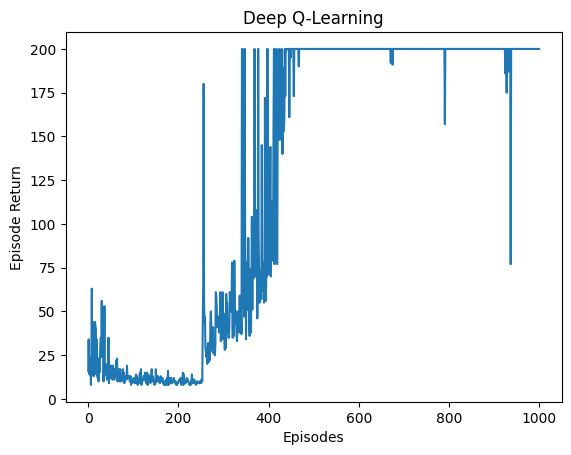

In [52]:
q_learning_select_action_jit = jax.jit(q_learning_select_action)
q_learn_jit                  = jax.jit(q_learn)

print("Starting training (Q-Learning). This may take up to 8 minutes...")
episode_returns, evaluator_returns = run_training_loop(
    env_name,
    Q_LEARNING_PARAMS,
    q_learning_select_action_jit,
    Q_LEARNING_ACTOR_STATE,
    q_learn_jit,
    Q_LEARNING_LEARN_STATE,
    Q_LEARNING_MEMORY,
    num_episodes=1001,
    train_every_timestep=True,
    video_subdir="q_learning"
)

plt.plot(episode_returns)
plt.xlabel("Episodes")
plt.ylabel("Episode Return")
plt.title("Deep Q-Learning")
plt.show()